# อ่านไฟล์ใน Assets แบบคร่าวๆ

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from IPython.display import display
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [48]:
dataframes = {}
for i in os.listdir('Assets'):
    print(f"อ่านไฟล์: {i}")
    dataframes[i] = pd.read_csv(os.path.join('Assets', i))
    display(dataframes[i].tail())
    print("-"*100)

อ่านไฟล์: stock_movement.csv


,stock_movement_id,datetime,store_id,product_id,qty
94,STK00095,2026-05-23 00:00:00,STR03,P008,5
95,STK00096,2026-05-25 00:00:00,STR03,P005,-2
96,STK00097,2026-05-25 00:00:00,STR03,P002,-2
97,STK00098,2026-05-19 00:00:00,STR01,P003,5
98,STK00099,2026-05-23 00:00:00,STR01,P012,-2


----------------------------------------------------------------------------------------------------
อ่านไฟล์: sales_transaction.csv


,sales_transaction_id,datetime,store_id,pos_id,product_id,qty
495,TX00496,2026-05-23 10:52:23,STR03,POS04,P015,1
496,TX00497,2026-05-24 17:22:07,STR03,POS02,P002,1
497,TX00498,2026-05-21 14:33:10,STR03,POS01,P009,2
498,TX00499,2026-05-26 07:57:28,STR02,POS01,P010,2
499,TX00500,2026-05-26 14:49:07,STR01,POS05,P009,1


----------------------------------------------------------------------------------------------------
อ่านไฟล์: purchasing_order.csv


,purchasing_order_id,warehouse_id,store_id,product_id,qty,arrival_date,expire_date
45,PO0046,WH01,STR03,P013,37,2026-05-22,2026-05-26
46,PO0047,WH01,STR01,P011,47,2026-05-20,2026-05-22
47,PO0048,WH01,STR03,P008,40,2026-05-21,2026-05-23
48,PO0049,WH01,STR01,P009,14,2026-05-19,2026-05-22
49,PO0050,WH01,STR01,P004,20,2026-05-21,2026-07-20


----------------------------------------------------------------------------------------------------
อ่านไฟล์: product_master.csv


,product_id,product_name,product_taxonomies
10,P011,Ham & Cheese Sandwich,Bakery
11,P012,Tuna Salad,Food
12,P013,Spaghetti Carbonara,Food
13,P014,Basil Pork Rice,Food
14,P015,Drinking Water,Beverage


----------------------------------------------------------------------------------------------------


# Merge ไฟล์ยอดขายกับชื่อสินค้า

In [49]:
sale_data = pd.merge(pd.read_csv('Assets/sales_transaction.csv', parse_dates=['datetime']),dataframes['product_master.csv'],on='product_id',how='inner')

sale_data.tail()

,sales_transaction_id,datetime,store_id,pos_id,product_id,qty,product_name,product_taxonomies
495,TX00496,2026-05-23 10:52:23,STR03,POS04,P015,1,Drinking Water,Beverage
496,TX00497,2026-05-24 17:22:07,STR03,POS02,P002,1,Americano,Beverage
497,TX00498,2026-05-21 14:33:10,STR03,POS01,P009,2,Orange Cake,Bakery
498,TX00499,2026-05-26 07:57:28,STR02,POS01,P010,2,Strawberry Shortcake,Bakery
499,TX00500,2026-05-26 14:49:07,STR01,POS05,P009,1,Orange Cake,Bakery


# EDA

## แบ่งช่วงเวลา

In [50]:
# Define time period function
def get_time_period(hour):
    if 7 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 15:
        return 'Afternoon'
    else:
        return 'Evening'

# Add hour and time_period
sale_data['hour'] = sale_data['datetime'].dt.hour
sale_data['time_period'] = sale_data['hour'].apply(get_time_period)

sale_data[['sales_transaction_id', 'product_name', 'product_taxonomies', 'qty', 'hour', 'time_period']].head()

,sales_transaction_id,product_name,product_taxonomies,qty,hour,time_period
0,TX00001,Ham & Cheese Sandwich,Bakery,2,10,Morning
1,TX00002,Chocolate Cake,Bakery,1,13,Afternoon
2,TX00003,Chocolate Frost,Beverage,1,14,Afternoon
3,TX00004,Orange Cake,Bakery,1,16,Evening
4,TX00005,Basil Pork Rice,Food,1,18,Evening


In [51]:
# Extract day-of-week features
sale_data['day_of_week'] = sale_data['datetime'].dt.day_name()
sale_data['day_of_week_num'] = sale_data['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
sale_data['is_weekend'] = sale_data['day_of_week'].isin(['Saturday', 'Sunday'])

print('✅ Day-of-week features extracted')
print(f'\nDistribution by day:')
day_dist = sale_data['day_of_week'].value_counts().sort_index()
display(day_dist)

print(f'\nWeekday vs Weekend:')
weekend_dist = sale_data['is_weekend'].value_counts()
print(f'  Weekday (Mon-Fri): {weekend_dist[False]:,} transactions')
print(f'  Weekend (Sat-Sun): {weekend_dist[True]:,} transactions')

# Show sample data with new columns
print(f'\nSample data:')
display(sale_data[['datetime', 'day_of_week', 'day_of_week_num', 'is_weekend', 'qty']].head(10))

✅ Day-of-week features extracted

Distribution by day:


day_of_week
Friday       75
Monday       60
Saturday     79
Sunday       86
Thursday     68
Tuesday      56
Wednesday    76
Name: count, dtype: int64


Weekday vs Weekend:
  Weekday (Mon-Fri): 335 transactions
  Weekend (Sat-Sun): 165 transactions

Sample data:


,datetime,day_of_week,day_of_week_num,is_weekend,qty
0,2026-05-26 10:28:14,Tuesday,1,False,2
1,2026-05-22 13:10:10,Friday,4,False,1
2,2026-05-21 14:43:29,Thursday,3,False,1
3,2026-05-23 16:21:43,Saturday,5,True,1
4,2026-05-23 18:15:14,Saturday,5,True,1
5,2026-05-23 13:51:56,Saturday,5,True,2
6,2026-05-20 13:17:03,Wednesday,2,False,3
7,2026-05-20 16:52:01,Wednesday,2,False,1
8,2026-05-24 14:46:34,Sunday,6,True,1
9,2026-05-21 12:53:41,Thursday,3,False,1


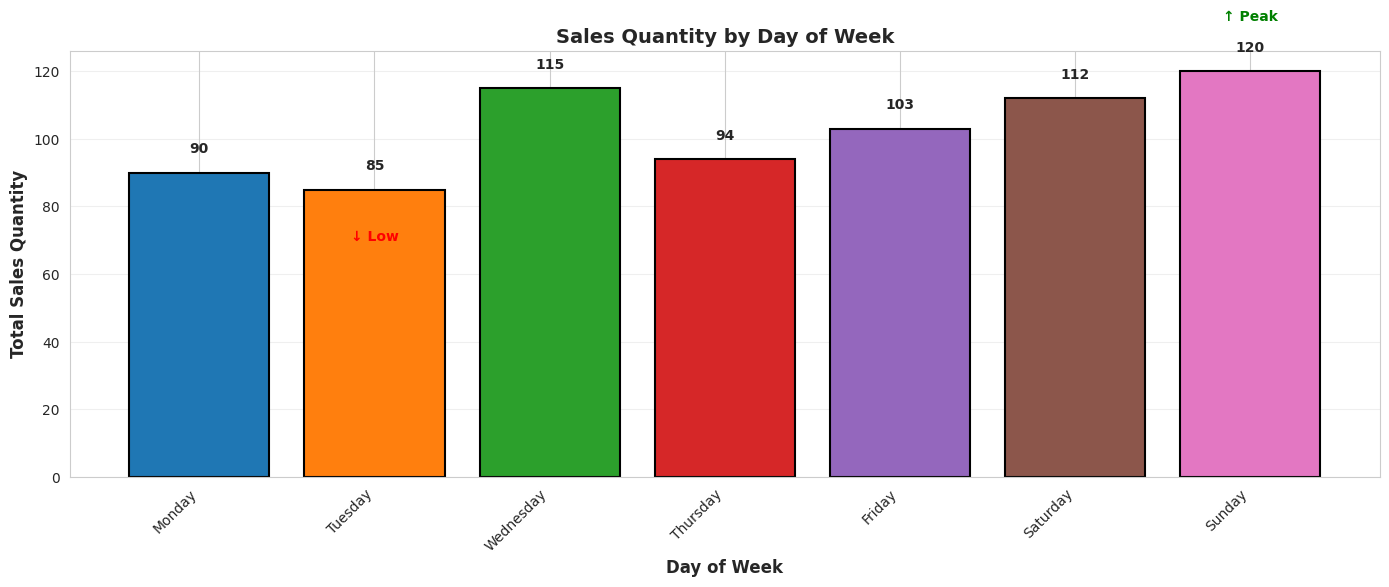

In [52]:
# Day-of-week sales analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = sale_data.groupby('day_of_week')['qty'].sum().reindex(day_order)
day_transactions = sale_data.groupby('day_of_week').size().reindex(day_order)

# Color mapping for each day
day_colors = {
    'Monday': '#1f77b4', 'Tuesday': '#ff7f0e', 'Wednesday': '#2ca02c',
    'Thursday': '#d62728', 'Friday': '#9467bd', 'Saturday': '#8c564b', 'Sunday': '#e377c2'
}
colors = [day_colors[day] for day in day_order]

# Create barplot
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(day_order)), day_sales.values, color=colors, edgecolor='black', linewidth=1.5)

ax.set_xticks(range(len(day_order)))
ax.set_xticklabels(day_order, rotation=45, ha='right')
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales Quantity', fontsize=12, fontweight='bold')
ax.set_title('Sales Quantity by Day of Week', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, value in enumerate(day_sales.values):
    ax.text(i, value + 5, str(int(value)), ha='center', va='bottom', fontweight='bold')

# Highlight peak and lowest
peak_day = day_sales.idxmax()
lowest_day = day_sales.idxmin()
peak_idx = day_order.index(peak_day)
lowest_idx = day_order.index(lowest_day)

ax.text(peak_idx, day_sales.max() + 15, '↑ Peak', ha='center', fontsize=10, fontweight='bold', color='green')
ax.text(lowest_idx, day_sales.min() - 15, '↓ Low', ha='center', fontsize=10, fontweight='bold', color='red')

plt.tight_layout()

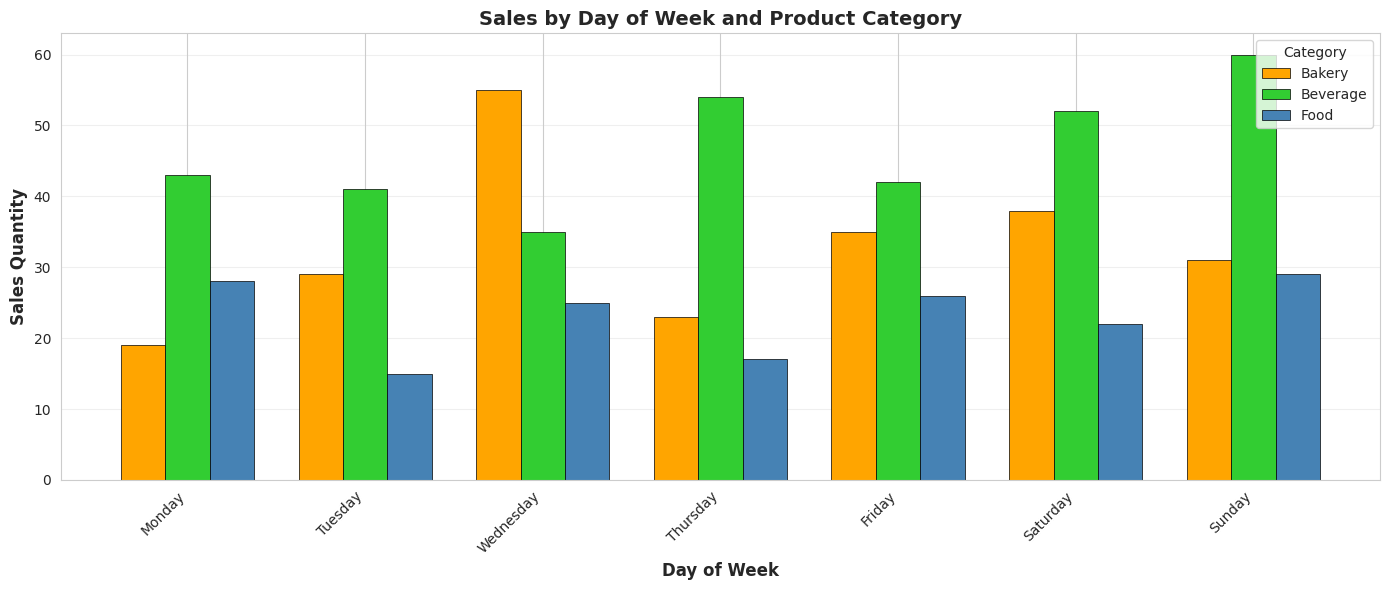

In [53]:
# Sales by day and product category
day_product = sale_data.groupby(['day_of_week', 'product_taxonomies'])['qty'].sum().unstack(fill_value=0)
day_product = day_product.reindex(day_order)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

category_colors = {'Beverage': 'limegreen', 'Food': 'steelblue', 'Bakery': 'orange'}
x = np.arange(len(day_order))
width = 0.25

for i, category in enumerate(day_product.columns):
    offset = (i - 1) * width
    ax.bar(x + offset, day_product[category].values, width, label=category, 
           color=category_colors.get(category, 'gray'), edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(day_order, rotation=45, ha='right')
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales Quantity', fontsize=12, fontweight='bold')
ax.set_title('Sales by Day of Week and Product Category', fontsize=14, fontweight='bold')
ax.legend(title='Category', loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

Weekday vs Weekend Comparison:


,Total Qty,Transaction Count,Avg Qty/Transaction
Weekday (Mon-Fri),487,335,1.45
Weekend (Sat-Sun),232,165,1.41


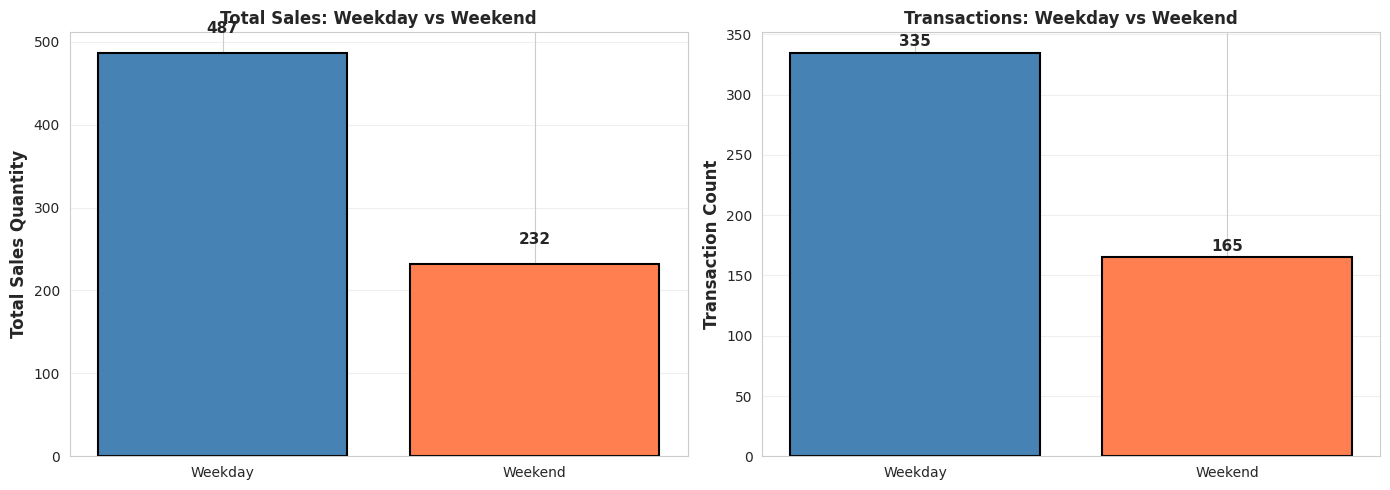

In [54]:
# Weekday vs Weekend summary
weekday_qty = sale_data[~sale_data['is_weekend']]['qty'].sum()
weekend_qty = sale_data[sale_data['is_weekend']]['qty'].sum()
weekday_count = sale_data[~sale_data['is_weekend']].shape[0]
weekend_count = sale_data[sale_data['is_weekend']].shape[0]

print('Weekday vs Weekend Comparison:')
summary_data = pd.DataFrame({
    'Total Qty': [weekday_qty, weekend_qty],
    'Transaction Count': [weekday_count, weekend_count],
    'Avg Qty/Transaction': [weekday_qty/weekday_count, weekend_qty/weekend_count]
}, index=['Weekday (Mon-Fri)', 'Weekend (Sat-Sun)'])
display(summary_data.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales quantity comparison
axes[0].bar(['Weekday', 'Weekend'], [weekday_qty, weekend_qty], color=['steelblue', 'coral'], edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Total Sales Quantity', fontsize=12, fontweight='bold')
axes[0].set_title('Total Sales: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, (label, value) in enumerate(zip(['Weekday', 'Weekend'], [weekday_qty, weekend_qty])):
    axes[0].text(i, value + 20, str(int(value)), ha='center', va='bottom', fontweight='bold', fontsize=11)

# Transaction count comparison
axes[1].bar(['Weekday', 'Weekend'], [weekday_count, weekend_count], color=['steelblue', 'coral'], edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Transaction Count', fontsize=12, fontweight='bold')
axes[1].set_title('Transactions: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, (label, value) in enumerate(zip(['Weekday', 'Weekend'], [weekday_count, weekend_count])):
    axes[1].text(i, value + 3, str(int(value)), ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()

Text(0.5, 0.995, 'Day-of-Week Sales Analysis Dashboard')

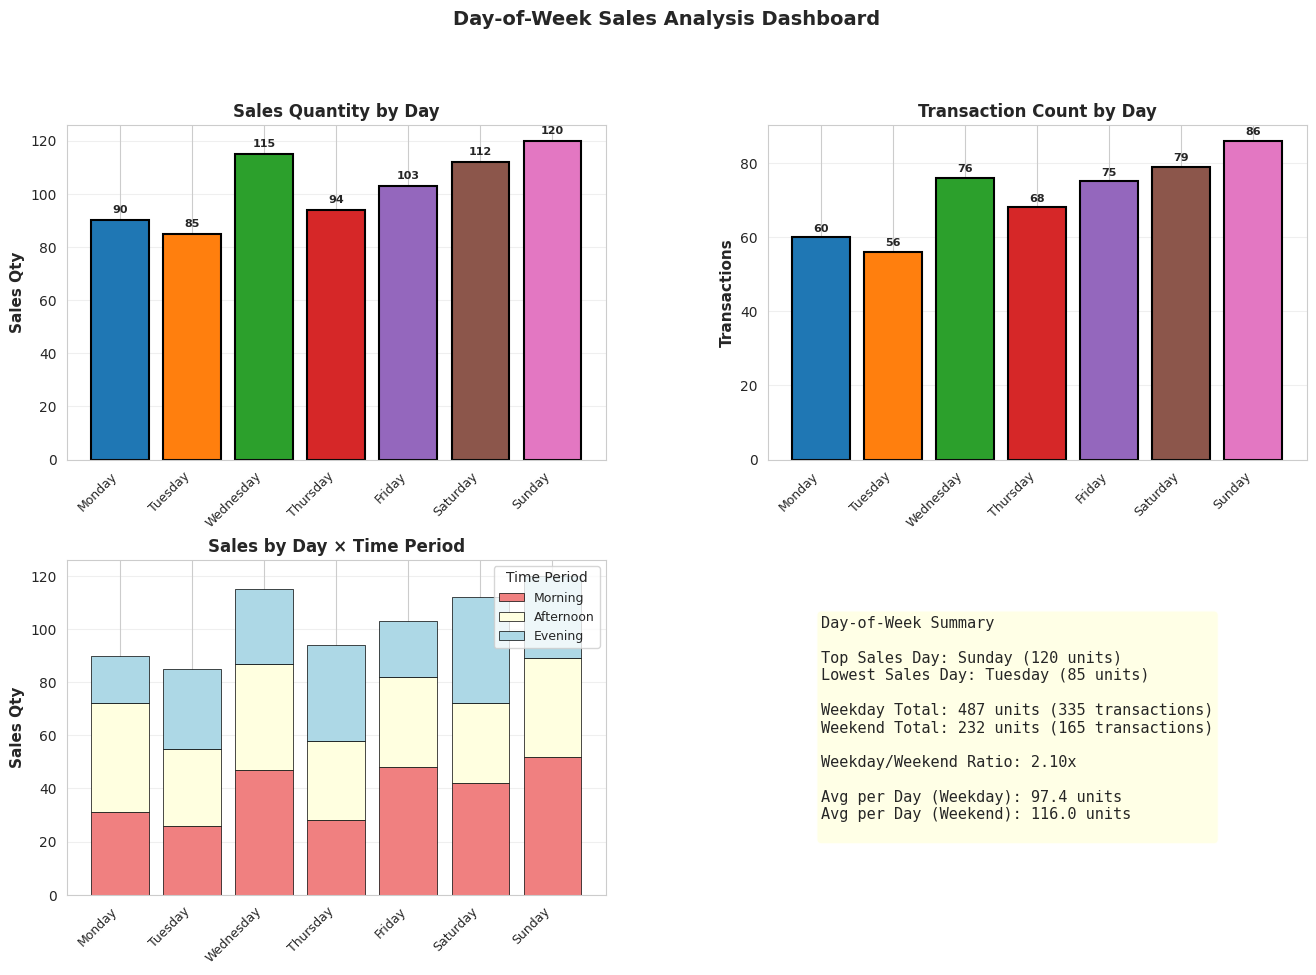

In [55]:
# Multi-metric day-of-week dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_colors = {'Monday': '#1f77b4', 'Tuesday': '#ff7f0e', 'Wednesday': '#2ca02c',
              'Thursday': '#d62728', 'Friday': '#9467bd', 'Saturday': '#8c564b', 'Sunday': '#e377c2'}
colors = [day_colors[day] for day in day_order]

time_period_order = ['Morning', 'Afternoon', 'Evening']

# Subplot 1: Sales quantity by day
ax1 = fig.add_subplot(gs[0, 0])
day_sales = sale_data.groupby('day_of_week')['qty'].sum().reindex(day_order)
ax1.bar(range(len(day_order)), day_sales.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(day_order)))
ax1.set_xticklabels(day_order, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Sales Qty', fontsize=11, fontweight='bold')
ax1.set_title('Sales Quantity by Day', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for i, v in enumerate(day_sales.values):
    ax1.text(i, v + 2, str(int(v)), ha='center', va='bottom', fontsize=8, fontweight='bold')

# Subplot 2: Transaction count by day
ax2 = fig.add_subplot(gs[0, 1])
day_count = sale_data.groupby('day_of_week').size().reindex(day_order)
ax2.bar(range(len(day_order)), day_count.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(day_order)))
ax2.set_xticklabels(day_order, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Transactions', fontsize=11, fontweight='bold')
ax2.set_title('Transaction Count by Day', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for i, v in enumerate(day_count.values):
    ax2.text(i, v + 1, str(int(v)), ha='center', va='bottom', fontsize=8, fontweight='bold')

# Subplot 3: Stacked bar by time period
ax3 = fig.add_subplot(gs[1, 0])
day_time = sale_data.groupby(['day_of_week', 'time_period'])['qty'].sum().unstack(fill_value=0)
day_time = day_time[time_period_order].reindex(day_order)

bottom = np.zeros(len(day_order))
time_colors = {'Morning': 'lightcoral', 'Afternoon': 'lightyellow', 'Evening': 'lightblue'}

for period in time_period_order:
    ax3.bar(range(len(day_order)), day_time[period].values, bottom=bottom, label=period,
            color=time_colors[period], edgecolor='black', linewidth=0.5)
    bottom += day_time[period].values

ax3.set_xticks(range(len(day_order)))
ax3.set_xticklabels(day_order, rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Sales Qty', fontsize=11, fontweight='bold')
ax3.set_title('Sales by Day × Time Period', fontsize=12, fontweight='bold')
ax3.legend(title='Time Period', fontsize=9, loc='upper right')
ax3.grid(axis='y', alpha=0.3)

# Subplot 4: Summary statistics
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

summary_text = f'''Day-of-Week Summary
\nTop Sales Day: {day_sales.idxmax()} ({day_sales.max():.0f} units)
Lowest Sales Day: {day_sales.idxmin()} ({day_sales.min():.0f} units)
\nWeekday Total: {weekday_qty:.0f} units ({weekday_count} transactions)
Weekend Total: {weekend_qty:.0f} units ({weekend_count} transactions)
\nWeekday/Weekend Ratio: {weekday_qty/weekend_qty:.2f}x
\nAvg per Day (Weekday): {weekday_qty/5:.1f} units
Avg per Day (Weekend): {weekend_qty/2:.1f} units
'''

ax4.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Day-of-Week Sales Analysis Dashboard', fontsize=14, fontweight='bold', y=0.995)

### หายอดขายแต่ละช่วงเวลา

In [56]:
hourly_sales = sale_data[['product_name', 'hour', 'qty']].groupby(['product_name', 'hour'])['qty'].sum().reset_index()
hourly_sales['time_period'] = hourly_sales['hour'].apply(get_time_period)

print("ได้ข้อมูลยอดขายพร้อมช่วงเวลาที่จัดกลุ่มเรียบร้อยแล้ว :")
summary = hourly_sales.groupby('time_period')['qty'].agg(['sum', 'count']).round(2)
summary.columns = ['Total Qty', 'Total Transactions']
summary['Average Qty per Transaction'] = (summary['Total Qty'] / summary['Total Transactions']).round(2)
display(summary.sort_values('Total Qty', ascending=False))

ได้ข้อมูลยอดขายพร้อมช่วงเวลาที่จัดกลุ่มเรียบร้อยแล้ว :


,Total Qty,Total Transactions,Average Qty per Transaction
time_period,,,
Morning,274,71,3.86
Afternoon,241,58,4.16
Evening,204,53,3.85


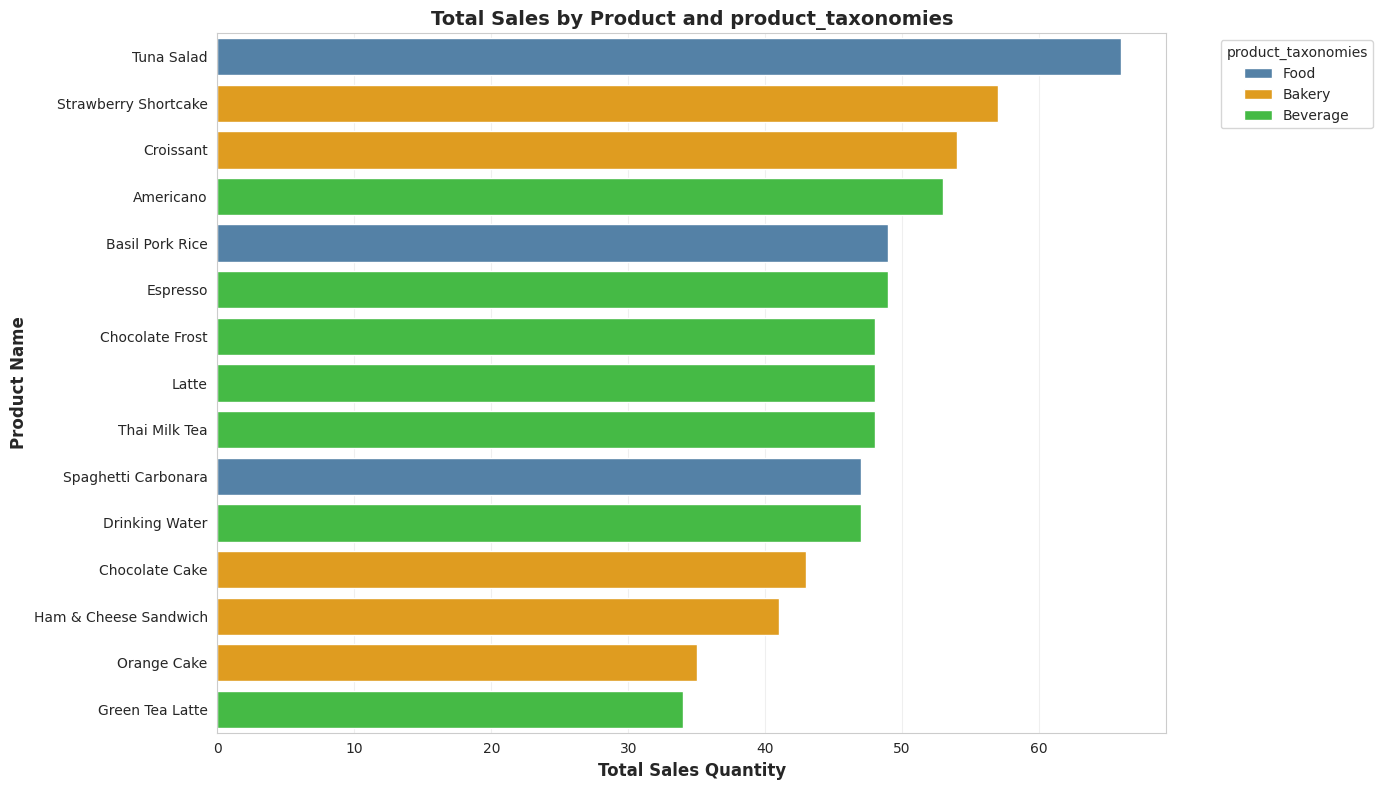

In [57]:
product_taxonomies_colors = {
    'Beverage': 'limegreen',
    'Food': 'steelblue',
    'Bakery': 'orange'
}

plot_data = sale_data.groupby(['product_name', 'product_taxonomies'])['qty'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='qty', y='product_name', hue='product_taxonomies', data=plot_data, palette=product_taxonomies_colors)
plt.xlabel('Total Sales Quantity', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')
plt.title('Total Sales by Product and product_taxonomies', fontsize=14, fontweight='bold')
plt.legend(title='product_taxonomies', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

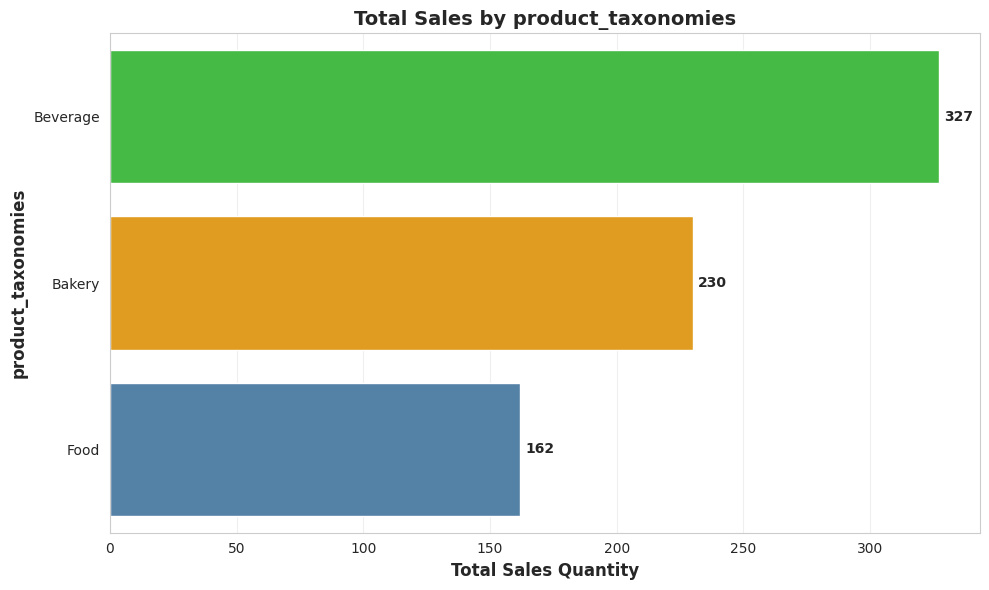

In [58]:
product_taxonomies_data = sale_data.groupby('product_taxonomies')['qty'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='qty', y='product_taxonomies', data=product_taxonomies_data, hue='product_taxonomies', palette=product_taxonomies_colors, legend=False)
plt.xlabel('Total Sales Quantity', fontsize=12, fontweight='bold')
plt.ylabel('product_taxonomies', fontsize=12, fontweight='bold')
plt.title('Total Sales by product_taxonomies', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(product_taxonomies_data['qty']):
    plt.text(v + 2, i, str(int(v)), va='center', fontweight='bold')
    
plt.tight_layout()

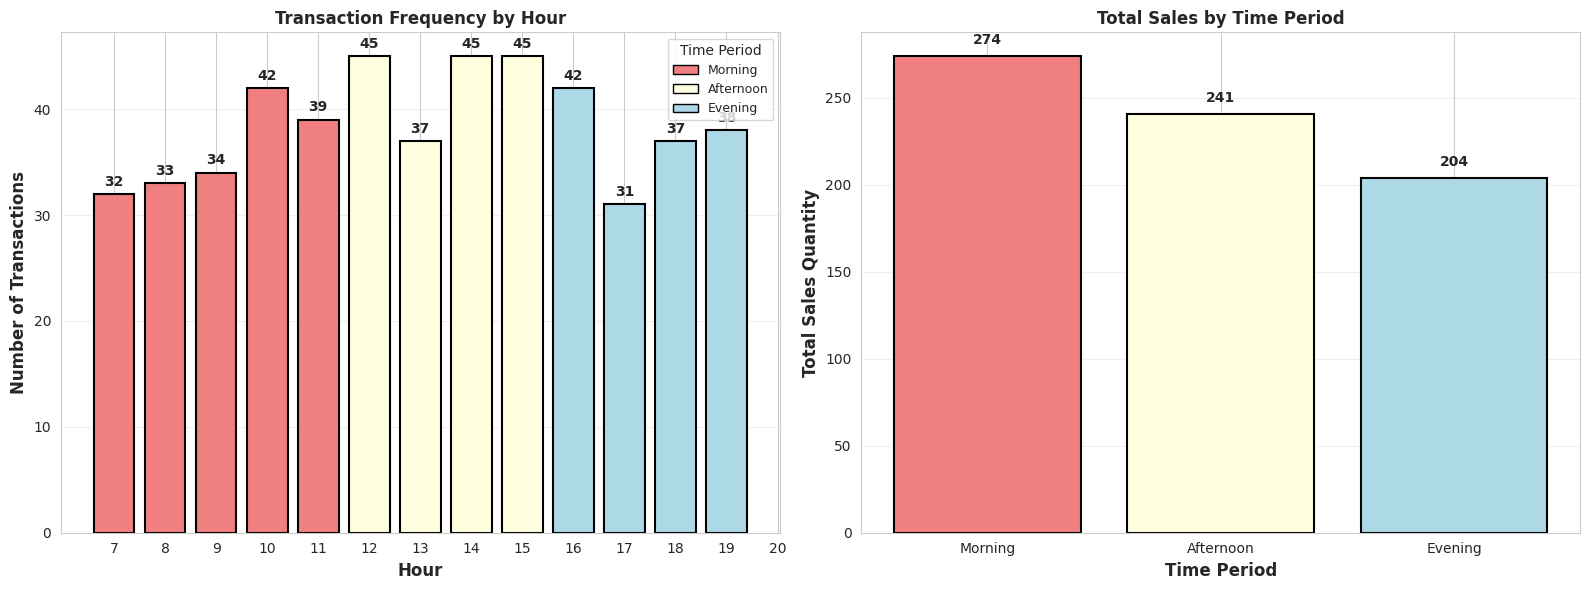

In [59]:
time_period_colors = {
    'Morning': 'lightcoral',
    'Afternoon': 'lightyellow',
    'Evening': 'lightblue'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT SUBPLOT: Transaction Frequency by Hour
transaction_by_hour = sale_data.groupby('hour').size().reset_index(name='transaction_count')
transaction_by_hour['time_period'] = transaction_by_hour['hour'].apply(get_time_period)

colors_list = [time_period_colors[transaction_by_hour.loc[idx, 'time_period']] for idx in range(len(transaction_by_hour))]
axes[0].bar(transaction_by_hour['hour'], transaction_by_hour['transaction_count'], color=colors_list, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Hour', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Transactions', fontsize=12, fontweight='bold')
axes[0].set_title('Transaction Frequency by Hour', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(7, 21))
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on left subplot
for hour, count in zip(transaction_by_hour['hour'], transaction_by_hour['transaction_count']):
    axes[0].text(hour, count + 0.5, str(int(count)), ha='center', va='bottom', fontweight='bold')

# Add legend for time periods
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=time_period_colors[period], edgecolor='black', label=period) for period in time_period_order]
axes[0].legend(handles=legend_elements, title='Time Period', loc='upper right', fontsize=9)

# RIGHT SUBPLOT: Sales Quantity by Time Period
time_period_data = sale_data.groupby('time_period')['qty'].sum().reindex(time_period_order)
colors = [time_period_colors.get(period, 'gray') for period in time_period_order]

axes[1].bar(time_period_data.index, time_period_data.values, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Time Period', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Sales Quantity', fontsize=12, fontweight='bold')
axes[1].set_title('Total Sales by Time Period', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on right subplot
for period, value in zip(time_period_data.index, time_period_data.values):
    axes[1].text(period, value + 5, str(int(value)), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

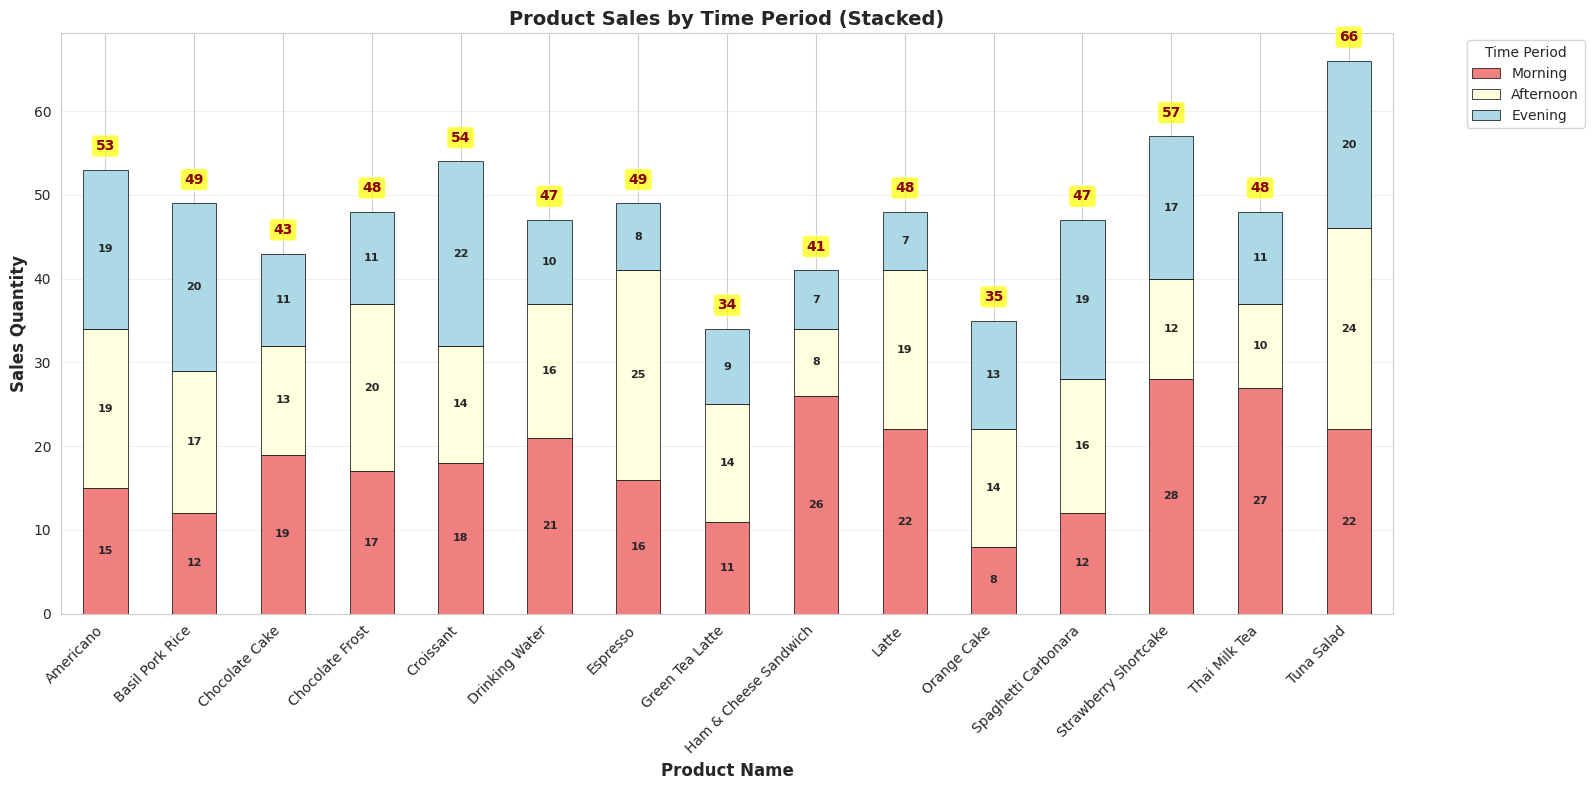

In [60]:
# Prepare data for stacked bar chart
pivot_data = sale_data.groupby(['product_name', 'time_period'])['qty'].sum().unstack(fill_value=0)
pivot_data = pivot_data[time_period_order]

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

pivot_data.plot(kind='bar', stacked=True, ax=ax,
                color=[time_period_colors[period] for period in time_period_order],
                edgecolor='black', linewidth=0.5)

ax.set_xlabel('Product Name', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales Quantity', fontsize=12, fontweight='bold')
ax.set_title('Product Sales by Time Period (Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Time Period', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Add numbers on segments
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontweight='bold', fontsize=8)

# Add totals on top
totals = pivot_data.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + 2, str(int(total)), ha='center', va='bottom',
            fontweight='bold', fontsize=10, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

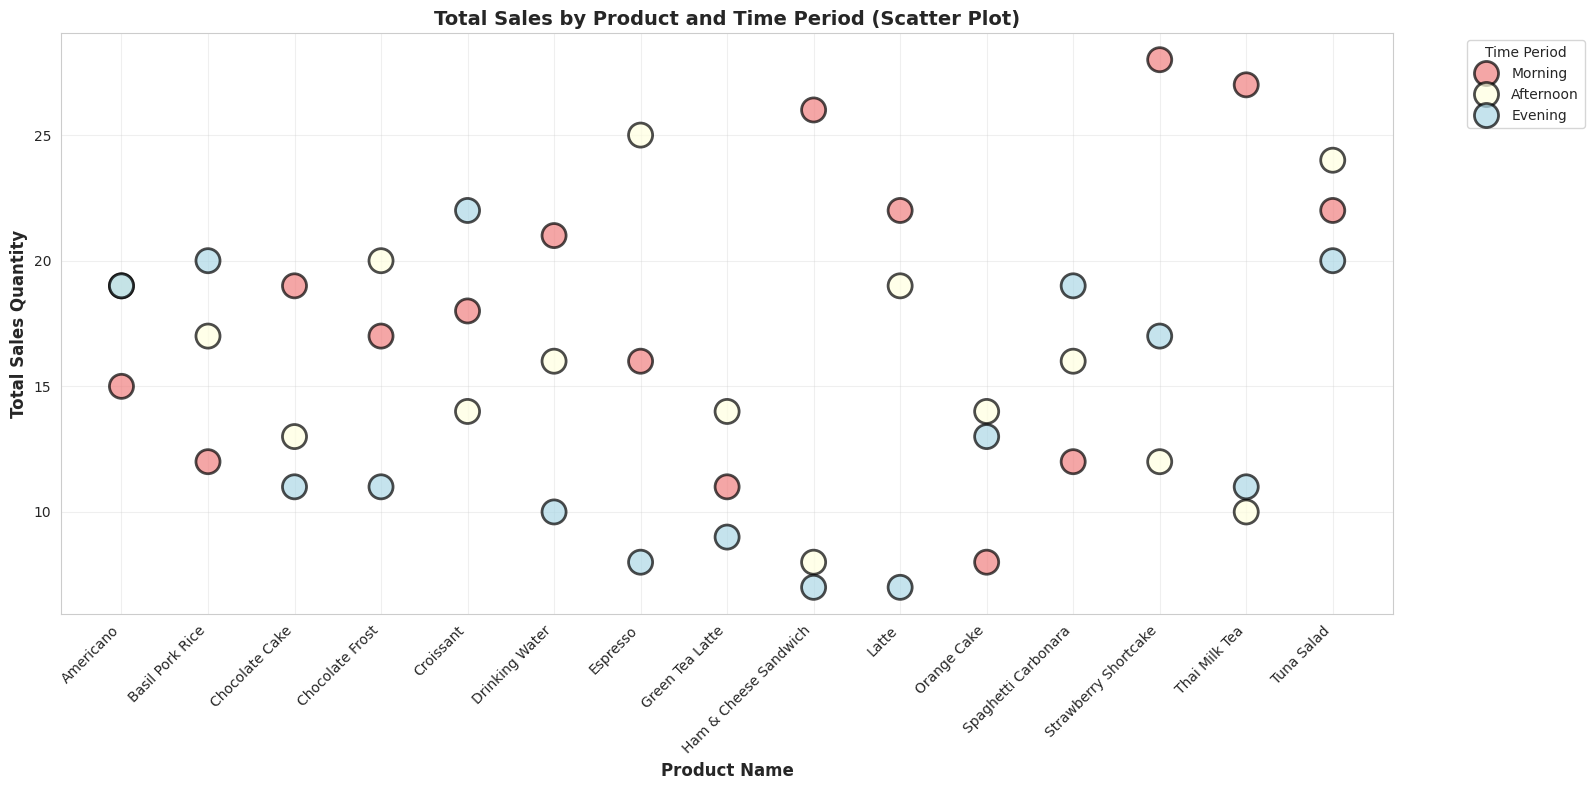

In [61]:
# Prepare data for scatter plot
scatter_data = sale_data.groupby(['product_name', 'time_period'])['qty'].sum().reset_index()

# Create scatter plot
plt.figure(figsize=(16, 8))
sns.scatterplot(
    data=scatter_data,
    x='product_name',
    y='qty',
    hue='time_period',
    hue_order=time_period_order,
    palette=time_period_colors,
    s=300,
    alpha=0.7,
    edgecolor='black',
    linewidth=2
)

plt.xlabel('Product Name', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales Quantity', fontsize=12, fontweight='bold')
plt.title('Total Sales by Product and Time Period (Scatter Plot)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Time Period', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

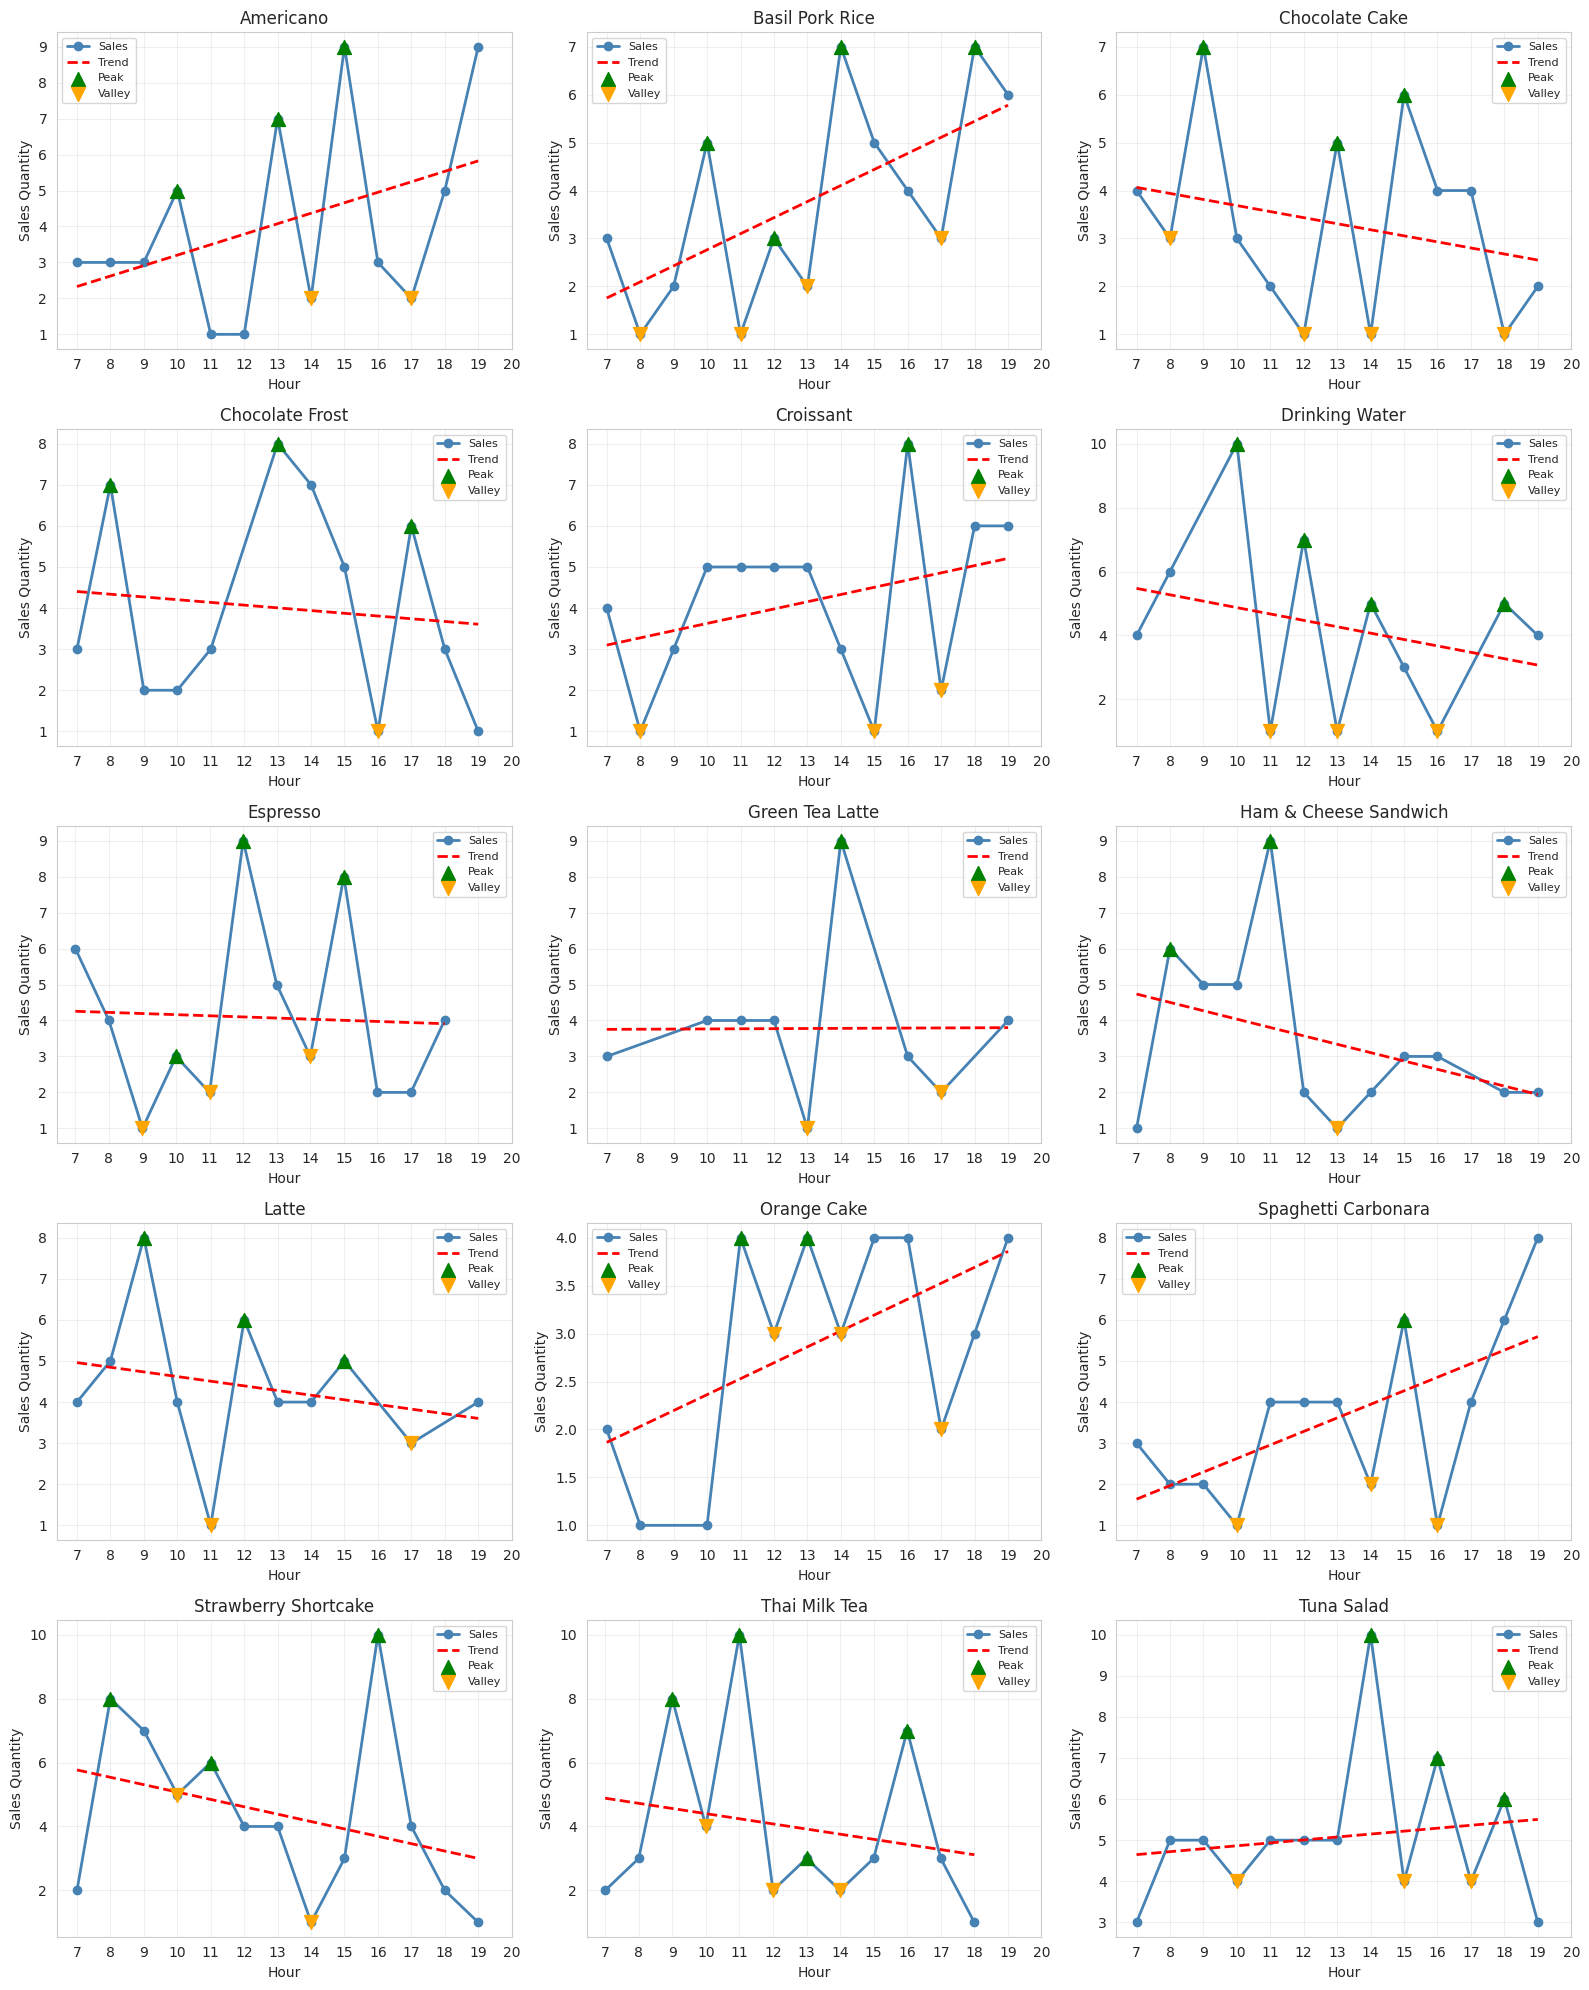

In [62]:
# Get unique products
products = sorted(hourly_sales['product_name'].unique())
num_products = len(products)
cols = 3
rows = (num_products + cols - 1) // cols

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

for idx, product in enumerate(products):
    product_data = hourly_sales[hourly_sales['product_name'] == product].sort_values('hour')
    hours = product_data['hour'].values
    quantities = product_data['qty'].values
    
    # Plot actual sales
    axes[idx].plot(hours, quantities, marker='o', linewidth=2, markersize=6, color='steelblue', label='Sales')
    
    # Add trend line
    z = np.polyfit(hours, quantities, 1)
    p = np.poly1d(z)
    trend_line = p(hours)
    axes[idx].plot(hours, trend_line, linestyle='--', linewidth=2, color='red', label='Trend')
    
    # Find changepoints
    local_max = argrelextrema(quantities, np.greater, order=1)[0]
    local_min = argrelextrema(quantities, np.less, order=1)[0]
    
    if len(local_max) > 0:
        axes[idx].scatter(hours[local_max], quantities[local_max], color='green', s=100, marker='^', label='Peak', zorder=5)
    if len(local_min) > 0:
        axes[idx].scatter(hours[local_min], quantities[local_min], color='orange', s=100, marker='v', label='Valley', zorder=5)
    
    axes[idx].set_xlabel('Hour')
    axes[idx].set_ylabel('Sales Quantity')
    axes[idx].set_title(f'{product}')
    axes[idx].set_xticks(range(7, 21))
    axes[idx].legend(loc='best', fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(num_products, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# =======================================
# INVENTORY & EXPIRY EDA
# =======================================
print("🏭 Starting Inventory & Expiry Analysis...\n")

## ส่วนที่ 1: โหลดและ Merge ข้อมูล Purchasing Order

In [63]:
po_data = pd.read_csv('Assets/purchasing_order.csv', parse_dates=['arrival_date', 'expire_date'])
po_data = pd.merge(po_data, dataframes['product_master.csv'], on='product_id', how='inner')

po_data['shelf_life_days'] = (po_data['expire_date'] - po_data['arrival_date']).dt.days

print(f"✅ Loaded purchasing_order data: {po_data.shape[0]} rows")
print(f"\nDate range:")
print(f"  Arrival: {po_data['arrival_date'].min().date()} to {po_data['arrival_date'].max().date()}")
print(f"  Expire: {po_data['expire_date'].min().date()} to {po_data['expire_date'].max().date()}")
print(f"\nShelf-life days distribution:")
display(po_data.groupby('product_taxonomies')['shelf_life_days'].describe().round(1))

print(f"\nSample purchasing orders:")
display(po_data[['purchasing_order_id', 'store_id', 'product_name', 'product_taxonomies', 'qty', 'arrival_date', 'expire_date', 'shelf_life_days']].head(10))

✅ Loaded purchasing_order data: 50 rows

Date range:
  Arrival: 2026-05-18 to 2026-05-22
  Expire: 2026-05-20 to 2026-07-21

Shelf-life days distribution:


,count,mean,std,min,25%,50%,75%,max
product_taxonomies,,,,,,,,
Bakery,15.0,2.7,0.8,2.0,2.0,3.0,3.0,4.0
Beverage,23.0,60.0,0.0,60.0,60.0,60.0,60.0,60.0
Food,12.0,2.8,0.9,2.0,2.0,2.5,3.2,4.0



Sample purchasing orders:


,purchasing_order_id,store_id,product_name,product_taxonomies,qty,arrival_date,expire_date,shelf_life_days
0,PO0001,STR01,Tuna Salad,Food,28,2026-05-20,2026-05-22,2
1,PO0002,STR02,Orange Cake,Bakery,24,2026-05-20,2026-05-23,3
2,PO0003,STR03,Latte,Beverage,15,2026-05-22,2026-07-21,60
3,PO0004,STR01,Chocolate Cake,Bakery,26,2026-05-21,2026-05-25,4
4,PO0005,STR01,Strawberry Shortcake,Bakery,36,2026-05-19,2026-05-21,2
5,PO0006,STR03,Orange Cake,Bakery,30,2026-05-19,2026-05-23,4
6,PO0007,STR01,Thai Milk Tea,Beverage,46,2026-05-20,2026-07-19,60
7,PO0008,STR03,Espresso,Beverage,26,2026-05-21,2026-07-20,60
8,PO0009,STR02,Green Tea Latte,Beverage,18,2026-05-18,2026-07-17,60
9,PO0010,STR03,Thai Milk Tea,Beverage,28,2026-05-21,2026-07-20,60


## ส่วนที่ 2: วิเคราะห์ Shelf-Life Distribution

📊 Shelf-Life Summary by Category:

Beverage:
  Min: 60, Max: 60, Mean: 60.0
  Count: 23 orders

Food:
  Min: 2, Max: 4, Mean: 2.8
  Count: 12 orders

Bakery:
  Min: 2, Max: 4, Mean: 2.7
  Count: 15 orders


/tmp/ipykernel_144425/1832171109.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(shelf_life_by_tax, labels=['Beverage', 'Food', 'Bakery'], patch_artist=True)


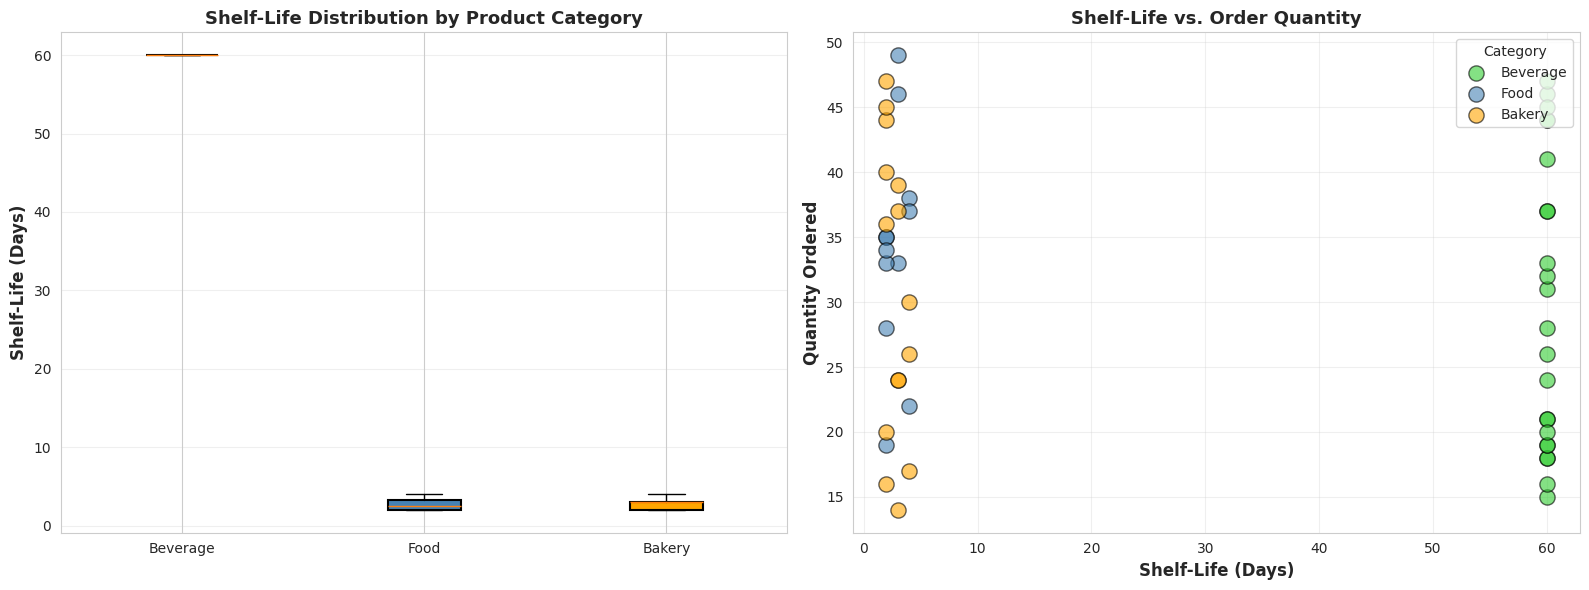

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

taxonomy_colors = {'Beverage': 'limegreen', 'Food': 'steelblue', 'Bakery': 'orange'}

# LEFT: Shelf-life distribution by taxonomy (box plot)
shelf_life_by_tax = [po_data[po_data['product_taxonomies'] == tax]['shelf_life_days'].values 
                      for tax in ['Beverage', 'Food', 'Bakery']]
bp = axes[0].boxplot(shelf_life_by_tax, labels=['Beverage', 'Food', 'Bakery'], patch_artist=True)

for patch, tax in zip(bp['boxes'], ['Beverage', 'Food', 'Bakery']):
    patch.set_facecolor(taxonomy_colors[tax])
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

axes[0].set_ylabel('Shelf-Life (Days)', fontsize=12, fontweight='bold')
axes[0].set_title('Shelf-Life Distribution by Product Category', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# RIGHT: Shelf-life vs. Quantity ordered (scatter)
for tax in ['Beverage', 'Food', 'Bakery']:
    tax_data = po_data[po_data['product_taxonomies'] == tax]
    axes[1].scatter(tax_data['shelf_life_days'], tax_data['qty'], 
                    s=120, alpha=0.6, label=tax, color=taxonomy_colors[tax], edgecolor='black', linewidth=1)

axes[1].set_xlabel('Shelf-Life (Days)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Quantity Ordered', fontsize=12, fontweight='bold')
axes[1].set_title('Shelf-Life vs. Order Quantity', fontsize=13, fontweight='bold')
axes[1].legend(title='Category', loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Summary statistics
print("📊 Shelf-Life Summary by Category:")
for tax in ['Beverage', 'Food', 'Bakery']:
    tax_data = po_data[po_data['product_taxonomies'] == tax]['shelf_life_days']
    print(f"\n{tax}:")
    print(f"  Min: {tax_data.min()}, Max: {tax_data.max()}, Mean: {tax_data.mean():.1f}")
    print(f"  Count: {len(tax_data)} orders")

## ส่วนที่ 3: วิเคราะห์ Expiry Risk (เทียบกับวันนี้ 2026-05-27)

📅 Expiry Risk Analysis (as of 2026-05-27):

Expiry Status Distribution:


expiry_status
Already Expired            27
Expiring Soon (≤3 days)     0
Safe (>3 days)             23
Name: count, dtype: int64


Risk Breakdown by Category:


expiry_status,Already Expired,Safe (>3 days),All
product_taxonomies,,,
Bakery,15,0,15
Beverage,0,23,23
Food,12,0,12
All,27,23,50



⚠️ Items at Risk (Expired or Expiring ≤3 days):


,purchasing_order_id,store_id,product_name,qty,expire_date,days_until_expire,expiry_status
0,PO0023,STR02,Spaghetti Carbonara,19,2026-05-20,-7,Already Expired
1,PO0022,STR03,Chocolate Cake,44,2026-05-20,-7,Already Expired
2,PO0043,STR03,Tuna Salad,35,2026-05-20,-7,Already Expired
3,PO0005,STR01,Strawberry Shortcake,36,2026-05-21,-6,Already Expired
4,PO0044,STR02,Tuna Salad,34,2026-05-21,-6,Already Expired
5,PO0033,STR02,Orange Cake,16,2026-05-21,-6,Already Expired
6,PO0029,STR02,Spaghetti Carbonara,35,2026-05-22,-5,Already Expired
7,PO0001,STR01,Tuna Salad,28,2026-05-22,-5,Already Expired
8,PO0045,STR03,Strawberry Shortcake,20,2026-05-22,-5,Already Expired
9,PO0038,STR01,Ham & Cheese Sandwich,17,2026-05-22,-5,Already Expired


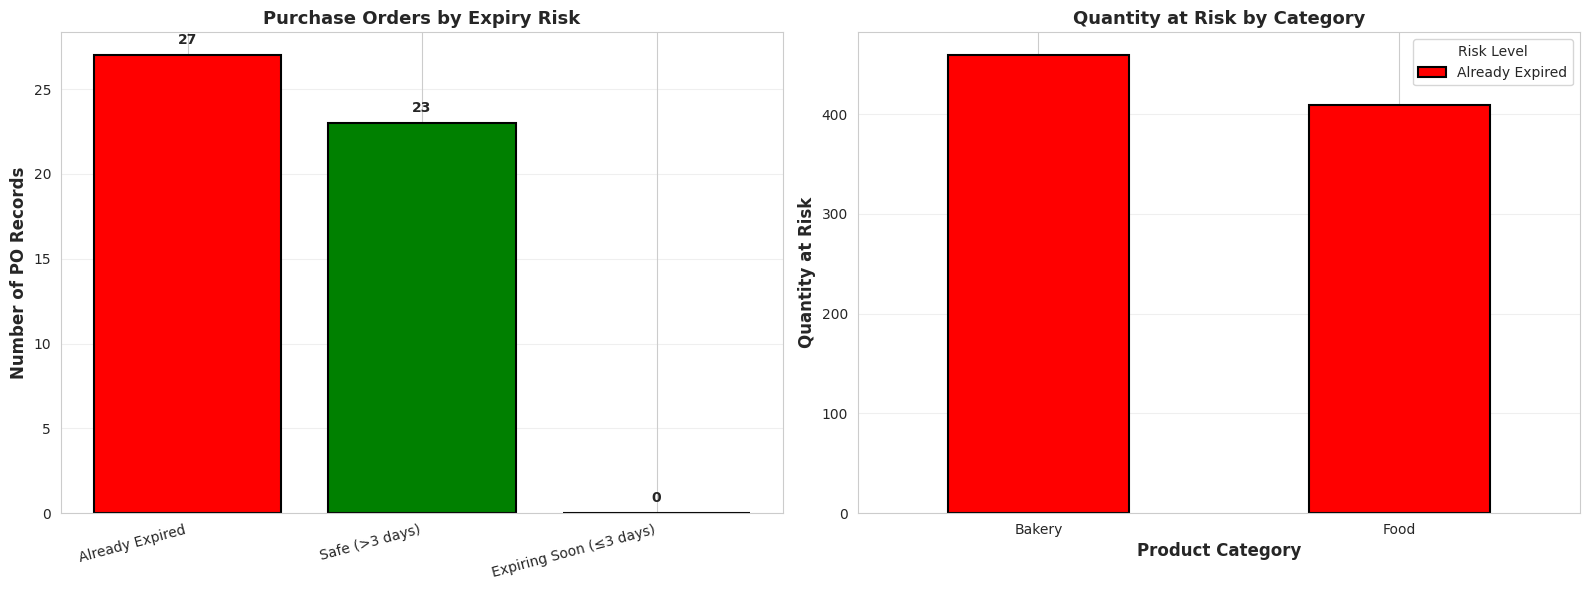

In [65]:
today = pd.Timestamp('2026-05-27')
po_data['days_until_expire'] = (po_data['expire_date'] - today).dt.days
po_data['expiry_status'] = pd.cut(po_data['days_until_expire'], 
                                  bins=[-np.inf, -1, 3, np.inf],
                                  labels=['Already Expired', 'Expiring Soon (≤3 days)', 'Safe (>3 days)'])

print(f"📅 Expiry Risk Analysis (as of {today.date()}):")
print(f"\nExpiry Status Distribution:")
expiry_summary = po_data['expiry_status'].value_counts().sort_index()
display(expiry_summary)

print(f"\nRisk Breakdown by Category:")
risk_by_tax = pd.crosstab(po_data['product_taxonomies'], po_data['expiry_status'], margins=True)
display(risk_by_tax)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

expiry_colors = {'Already Expired': 'red', 'Expiring Soon (≤3 days)': 'orange', 'Safe (>3 days)': 'green'}

# LEFT: Expiry status count
expiry_count = po_data['expiry_status'].value_counts()
colors = [expiry_colors[status] for status in expiry_count.index]
bars = axes[0].bar(range(len(expiry_count)), expiry_count.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(expiry_count)))
axes[0].set_xticklabels(expiry_count.index, rotation=15, ha='right')
axes[0].set_ylabel('Number of PO Records', fontsize=12, fontweight='bold')
axes[0].set_title('Purchase Orders by Expiry Risk', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, (status, value) in enumerate(zip(expiry_count.index, expiry_count.values)):
    axes[0].text(i, value + 0.5, str(int(value)), ha='center', va='bottom', fontweight='bold')

# RIGHT: Quantity at risk by category
risk_qty = po_data[po_data['expiry_status'] != 'Safe (>3 days)'].groupby(['product_taxonomies', 'expiry_status'])['qty'].sum().unstack(fill_value=0)

if not risk_qty.empty:
    risk_qty.plot(kind='bar', ax=axes[1], color=['red', 'orange'], edgecolor='black', linewidth=1.5)
    axes[1].set_xlabel('Product Category', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Quantity at Risk', fontsize=12, fontweight='bold')
    axes[1].set_title('Quantity at Risk by Category', fontsize=13, fontweight='bold')
    axes[1].legend(title='Risk Level', loc='upper right')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
else:
    axes[1].text(0.5, 0.5, 'No immediate risk items', ha='center', va='center', fontsize=14)
    axes[1].axis('off')

plt.tight_layout()

# Detailed list of at-risk items
print(f"\n⚠️ Items at Risk (Expired or Expiring ≤3 days):")
at_risk = po_data[po_data['expiry_status'] != 'Safe (>3 days)'].sort_values('days_until_expire')
if len(at_risk) > 0:
    display(at_risk[['purchasing_order_id', 'store_id', 'product_name', 'qty', 'expire_date', 'days_until_expire', 'expiry_status']].reset_index(drop=True))
else:
    print("✅ No items at risk!")

## ส่วนที่ 4: คำนวณ Current Stock Level

✅ Loaded stock_movement data: 99 records
📦 Current stock levels calculated for 38 store-product combinations

Stock Movement Summary:
  Total Inbound (+): 720 units
  Total Outbound (-): -118 units

Current Stock by Store:


store_id
STR03    305
STR02    181
STR01    116
Name: current_stock_qty, dtype: int64


Current Stock by Product (Top 10):


product_id  product_name         
P001        Espresso                 81
P010        Strawberry Shortcake     73
P007        Croissant                70
P006        Chocolate Frost          66
P015        Drinking Water           65
P009        Orange Cake              48
P014        Basil Pork Rice          48
P004        Green Tea Latte          46
P011        Ham & Cheese Sandwich    43
P002        Americano                28
Name: current_stock_qty, dtype: int64


Current Stock by Product Category:


,sum,mean,std
product_taxonomies,,,
Bakery,236,18.15,16.48
Beverage,322,17.89,16.47
Food,44,6.29,10.72


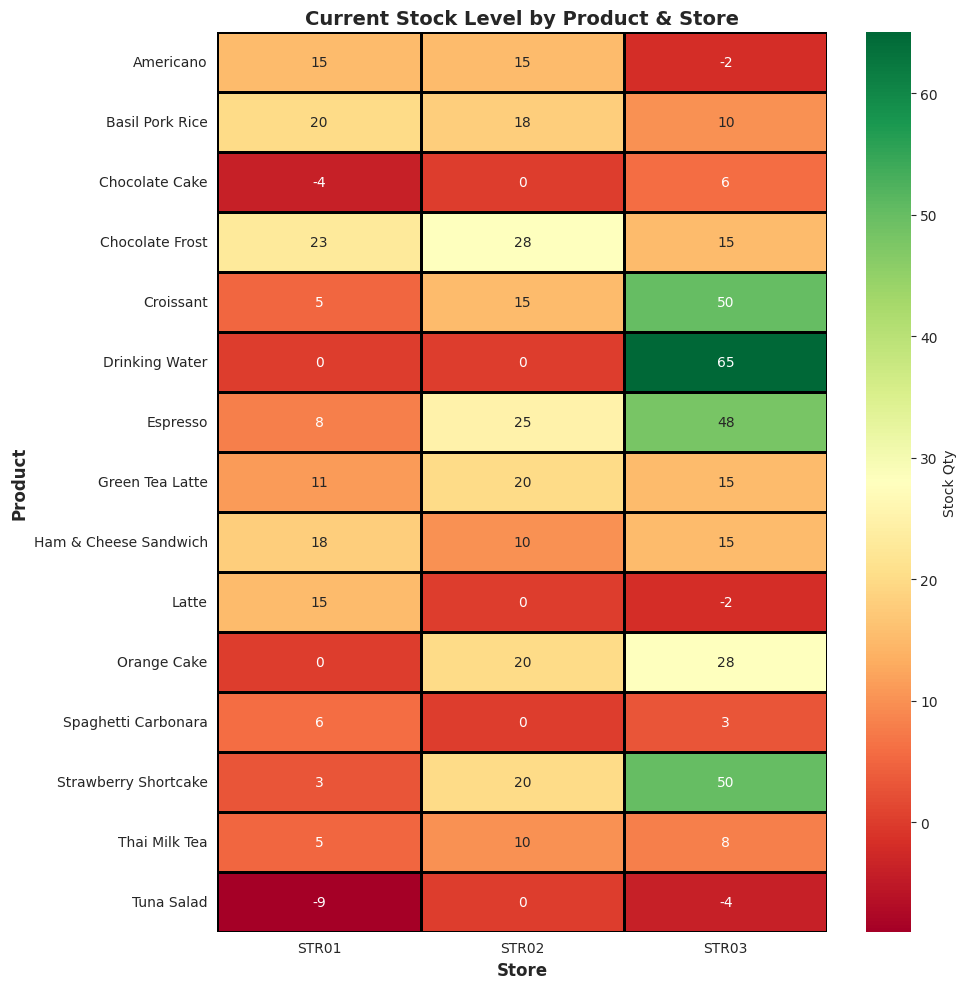

In [66]:
stock_movement = pd.read_csv('Assets/stock_movement.csv', parse_dates=['datetime'])

current_stock = stock_movement.groupby(['store_id', 'product_id'])['qty'].sum().reset_index()
current_stock.columns = ['store_id', 'product_id', 'current_stock_qty']

current_stock = pd.merge(current_stock, dataframes['product_master.csv'], on='product_id', how='left')

print(f"✅ Loaded stock_movement data: {stock_movement.shape[0]} records")
print(f"📦 Current stock levels calculated for {len(current_stock)} store-product combinations")

print(f"\nStock Movement Summary:")
print(f"  Total Inbound (+): {stock_movement[stock_movement['qty'] > 0]['qty'].sum()} units")
print(f"  Total Outbound (-): {stock_movement[stock_movement['qty'] < 0]['qty'].sum()} units")

print(f"\nCurrent Stock by Store:")
stock_by_store = current_stock.groupby('store_id')['current_stock_qty'].sum().sort_values(ascending=False)
display(stock_by_store)

print(f"\nCurrent Stock by Product (Top 10):")
stock_by_product = current_stock.groupby(['product_id', 'product_name'])['current_stock_qty'].sum().sort_values(ascending=False).head(10)
display(stock_by_product)

# Heatmap: Product × Store stock levels
pivot_stock = current_stock.pivot_table(index='product_name', columns='store_id', values='current_stock_qty', fill_value=0)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(pivot_stock, annot=True, fmt='.0f', cmap='RdYlGn', cbar_kws={'label': 'Stock Qty'}, 
            linewidths=1, linecolor='black', ax=ax)
ax.set_title('Current Stock Level by Product & Store', fontsize=14, fontweight='bold')
ax.set_xlabel('Store', fontsize=12, fontweight='bold')
ax.set_ylabel('Product', fontsize=12, fontweight='bold')
plt.tight_layout()

# Stock distribution by category
print(f"\nCurrent Stock by Product Category:")
stock_by_category = current_stock.groupby('product_taxonomies')['current_stock_qty'].agg(['sum', 'mean', 'std']).round(2)
display(stock_by_category)

## ส่วนที่ 5: วิเคราะห์ Sell-Through Rate (เชื่อมกับ Sales EDA)

🛍️ Sell-Through Analysis:

Sell-Through Rates by Product:


,product_id,product_name,product_taxonomies,qty_purchased,qty_sold,shelf_life_days,sell_through_rate
0,P014,Basil Pork Rice,Food,33,49,2,148.48
1,P010,Strawberry Shortcake,Bakery,56,57,2,101.79
2,P003,Latte,Beverage,62,48,60,77.42
3,P002,Americano,Beverage,88,53,60,60.23
4,P004,Green Tea Latte,Beverage,59,34,60,57.63
5,P001,Espresso,Beverage,91,49,60,53.85
6,P005,Thai Milk Tea,Beverage,109,48,60,44.04
7,P015,Drinking Water,Beverage,124,47,60,37.90
8,P009,Orange Cake,Bakery,108,35,2,32.41
9,P009,Orange Cake,Bakery,108,35,4,32.41



Sell-Through Statistics by Category:


,count,mean,min,max
product_taxonomies,,,,
Bakery,10,36.99,27.70,101.79
Beverage,7,51.90,32.21,77.42
Food,7,46.86,29.01,148.48



⚠️ CRITICAL: Short Shelf-Life Items with Low Sell-Through (<50%):


,product_name,product_taxonomies,qty_purchased,qty_sold,shelf_life_days,sell_through_rate
0,Orange Cake,Bakery,108,35,2,32.41
1,Orange Cake,Bakery,108,35,4,32.41
2,Orange Cake,Bakery,108,35,3,32.41
3,Tuna Salad,Food,214,66,4,30.84
4,Tuna Salad,Food,214,66,2,30.84
5,Tuna Salad,Food,214,66,3,30.84
6,Chocolate Cake,Bakery,147,43,4,29.25
7,Chocolate Cake,Bakery,147,43,3,29.25
8,Chocolate Cake,Bakery,147,43,2,29.25
9,Spaghetti Carbonara,Food,162,47,4,29.01


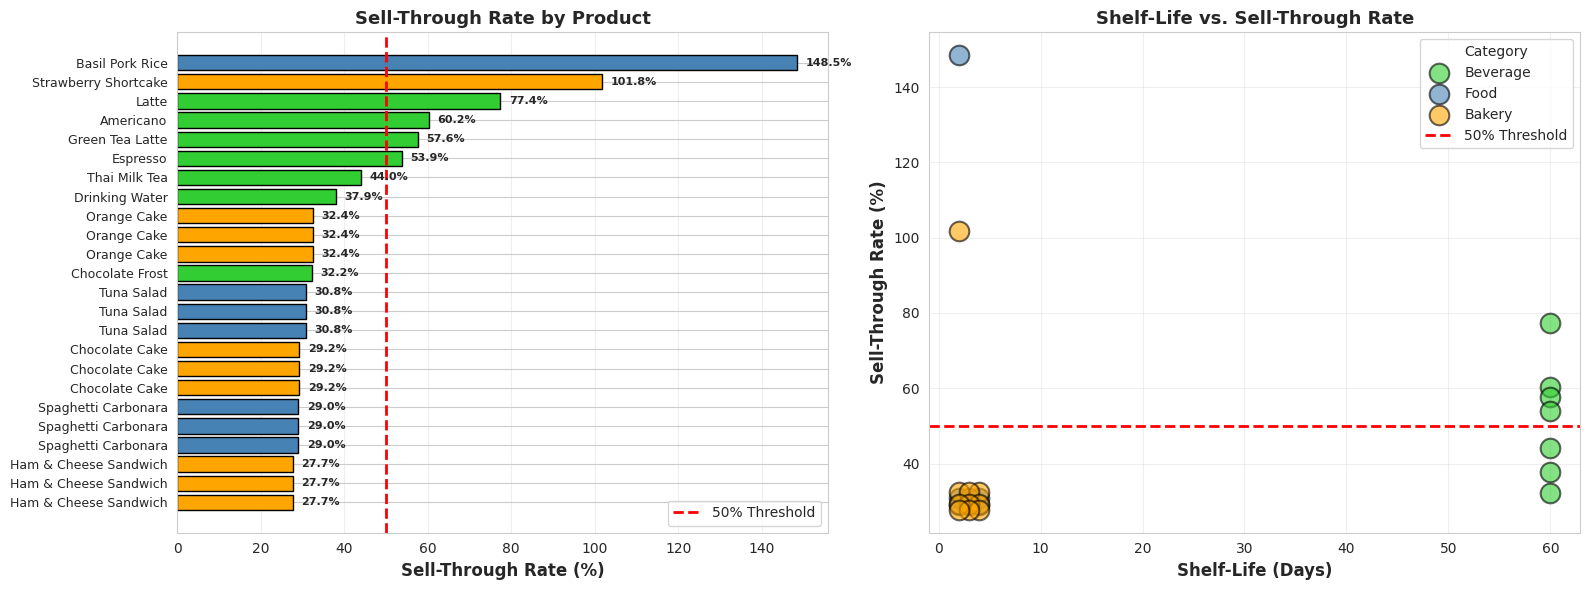

In [67]:
qty_purchased = po_data.groupby('product_id')['qty'].sum().reset_index()
qty_purchased.columns = ['product_id', 'qty_purchased']

qty_sold = sale_data.groupby('product_id')['qty'].sum().reset_index()
qty_sold.columns = ['product_id', 'qty_sold']

sell_through = pd.merge(qty_purchased, qty_sold, on='product_id', how='left')
sell_through['qty_sold'] = sell_through['qty_sold'].fillna(0)
sell_through['sell_through_rate'] = (sell_through['qty_sold'] / sell_through['qty_purchased'] * 100).round(2)

sell_through = pd.merge(sell_through, dataframes['product_master.csv'], on='product_id', how='left')
sell_through = pd.merge(sell_through, po_data[['product_id', 'shelf_life_days']].drop_duplicates(), on='product_id', how='left')

sell_through = sell_through.sort_values('sell_through_rate', ascending=False)

print(f"🛍️ Sell-Through Analysis:")
print(f"\nSell-Through Rates by Product:")
display(sell_through[['product_id', 'product_name', 'product_taxonomies', 'qty_purchased', 'qty_sold', 'shelf_life_days', 'sell_through_rate']].reset_index(drop=True))

print(f"\nSell-Through Statistics by Category:")
str_by_category = sell_through.groupby('product_taxonomies')['sell_through_rate'].agg(['count', 'mean', 'min', 'max']).round(2)
display(str_by_category)

# Identify risk items (short shelf-life with low sell-through)
print(f"\n⚠️ CRITICAL: Short Shelf-Life Items with Low Sell-Through (<50%):")
high_risk = sell_through[(sell_through['shelf_life_days'] <= 4) & (sell_through['sell_through_rate'] < 50)]
if len(high_risk) > 0:
    display(high_risk[['product_name', 'product_taxonomies', 'qty_purchased', 'qty_sold', 'shelf_life_days', 'sell_through_rate']].reset_index(drop=True))
else:
    print("✅ All short shelf-life items have acceptable sell-through rates!")

# Visualization: Sell-Through Rate by Product
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Sell-through rate by product
sell_through_sorted = sell_through.sort_values('sell_through_rate')
colors = [taxonomy_colors.get(tax, 'gray') for tax in sell_through_sorted['product_taxonomies']]
bars = axes[0].barh(range(len(sell_through_sorted)), sell_through_sorted['sell_through_rate'], color=colors, edgecolor='black', linewidth=1)
axes[0].set_yticks(range(len(sell_through_sorted)))
axes[0].set_yticklabels(sell_through_sorted['product_name'], fontsize=9)
axes[0].set_xlabel('Sell-Through Rate (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Sell-Through Rate by Product', fontsize=13, fontweight='bold')
axes[0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% Threshold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].legend()

# Add value labels
for i, (idx, row) in enumerate(sell_through_sorted.iterrows()):
    axes[0].text(row['sell_through_rate'] + 2, i, f"{row['sell_through_rate']:.1f}%", va='center', fontweight='bold', fontsize=8)

# RIGHT: Shelf-Life vs Sell-Through Rate (scatter)
for tax in ['Beverage', 'Food', 'Bakery']:
    tax_data = sell_through[sell_through['product_taxonomies'] == tax]
    axes[1].scatter(tax_data['shelf_life_days'], tax_data['sell_through_rate'], 
                    s=200, alpha=0.6, label=tax, color=taxonomy_colors[tax], edgecolor='black', linewidth=1.5)

axes[1].set_xlabel('Shelf-Life (Days)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sell-Through Rate (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Shelf-Life vs. Sell-Through Rate', fontsize=13, fontweight='bold')
axes[1].axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% Threshold')
axes[1].legend(title='Category', loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()